# Kompresja obrazów metodą SVD

Projekt demonstruje zastosowanie **rozkładu SVD** (Singular Value Decomposition) do kompresji i filtrowania obrazów bitmapowych. Omówione są:
- zasada działania SVD w kontekście obrazów,
- wskaźnik kompresji,
- generyczna funkcja filtrująca wartości osobliwe,
- porównanie efektywności dla 4 typów obrazów.

## 1. Importy

Importy obejmują podstawowe biblioteki numeryczne, graficzne i obsługę obrazów. Ustawienia wykresów stabilizują wygląd figur w całym notatniku, a stała `IMAGES_DIR` wskazuje lokalizację danych wejściowych.

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

IMAGES_DIR = Path('images')

## 2. Teoria SVD

Każdą macierz $A \in \mathbb{R}^{m \times n}$ można rozłożyć jako:

$$A = U \Sigma V^T$$

gdzie:
- $U \in \mathbb{R}^{m \times m}$ – macierz ortonormalna (lewe wektory osobliwe),
- $\Sigma \in \mathbb{R}^{m \times n}$ – macierz diagonalna z wartościami osobliwymi $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$,
- $V^T \in \mathbb{R}^{n \times n}$ – macierz ortonormalna (prawe wektory osobliwe).

### Kompresja rank-$k$

Zachowujemy tylko $k$ największych wartości osobliwych:

$$A_k = \sum_{i=1}^{k} \sigma_i \, u_i \, v_i^T = U_{:,1:k} \; \text{diag}(\sigma_1,\ldots,\sigma_k) \; V^T_{1:k,:}$$

Twierdzenie Eckarta-Younga gwarantuje, że $A_k$ jest najlepszym przybliżeniem rzędu $k$ w normie Frobeniusa i spektralnej.

### Wskaźnik kompresji

- Oryginał przechowuje $mn$ liczb.
- Po kompresji SVD-$k$ przechowujemy $k(m+n+1)$ liczb (U: $m \times k$, S: $k$, Vt: $k \times n$).
- Wskaźnik kompresji: $r = \frac{k(m+n+1)}{mn}$.
- Interpretacja: $r<1$ oznacza realną oszczędność miejsca, $r>1$ brak zysku.

### Jakość rekonstrukcji

- MSE mierzy średnią różnicę pikseli.
- PSNR to logarytmiczna miara jakości:
$$\text{PSNR} = 10 \log_{10}\left(\frac{\text{MAX}^2}{\text{MSE}}\right), \quad \text{MAX}=255$$
- Wyższy PSNR oznacza lepszą jakość.

### Energia spektrum i efektywny rząd

Skumulowana energia wartości osobliwych (np. 99% lub 99.9%) mówi, ile składowych potrzeba do wiernej rekonstrukcji. Efektywny rząd to najmniejsze $k$, które przekracza zadany próg energii.

### Kolor vs. skala szarości

Dla obrazów kolorowych SVD wykonuje się osobno na każdym kanale (RGB lub YCbCr), a następnie składa zrekonstruowane kanały w całość.

### Filtracja wartości osobliwych

Modyfikacja wektora $S$ (top-$k$, progowanie twarde lub miękkie) pozwala sterować kompromisem jakość/rozmiar. Wycinanie małych $\sigma_i$ usuwa detale i powoduje rozmycie, ale redukuje szum.

### Rodzaj obrazu ma znaczenie

- Diagramy i fonty: szybki spadek wartości osobliwych (łatwa kompresja).
- Pejzaże: wolniejszy spadek (więcej detali do zachowania).

## 3. Funkcje podstawowe

W tej sekcji definiowane są metryki i funkcje pomocnicze potrzebne do oceny kompresji. Zawierają one formalny opis wskaźnika kompresji oraz jakości rekonstrukcji poprzez MSE i PSNR.

In [2]:
def compression_ratio(m: int, n: int, k: int) -> float:
    """
    Stosunek liczby przechowywanych wartości po kompresji do oryginalnej.

    Oryginał:   m * n
    Po SVD-k:   k*(m + n + 1)  (U: m*k, S: k, Vt: k*n)

    Zwraca wartość < 1 jeśli kompresja jest korzystna.
    """
    return k * (m + n + 1) / (m * n)


def max_k_for_ratio(m: int, n: int, ratio: float) -> int:
    """Maksymalne k dla zadanego wskaźnika kompresji."""
    return max(1, int(ratio * m * n / (m + n + 1)))


def mse(original: np.ndarray, reconstructed: np.ndarray) -> float:
    """Średni błąd kwadratowy (0–255 zakres)."""
    return float(np.mean((original.astype(float) - reconstructed.astype(float)) ** 2))


def psnr(original: np.ndarray, reconstructed: np.ndarray, max_val: float = 255.0) -> float:
    """Peak Signal-to-Noise Ratio w dB. Wyższy = lepsza jakość."""
    err = mse(original, reconstructed)
    if err == 0:
        return float('inf')
    return 10 * np.log10(max_val ** 2 / err)

## 4. Implementacja SVD

W implementacji wykorzystano zależności:

$$
A^T A = V \Sigma^2 V^T
$$

oraz

$$
A A^T = U \Sigma^2 U^T
$$

Oznacza to, że wartości własne macierzy $A^T A$ lub $AA^T$ są równe $\sigma_i^2$, a pierwiastki z tych wartości własnych dają wartości osobliwe. Odpowiadające im wektory własne tworzą macierze $U$ oraz $V$.

Klasyczna definicja SVD ma postać:

$$
A = U \Sigma V^T
$$

Z tej definicji wynika, że:

$$
A^T A = (U \Sigma V^T)^T (U \Sigma V^T)
$$

Po przekształceniu transpozycji otrzymujemy:

$$
A^T A = (V \Sigma U^T)(U \Sigma V^T)
$$

Ponieważ macierz $U$ jest ortogonalna, zachodzi $U^T U = I$, więc:

$$
A^T A = V \Sigma I \Sigma V^T
$$

co upraszcza się do:

$$
A^T A = V \Sigma^2 V^T
$$

Z tego wynika, że kolumny macierzy $V$ są wektorami własnymi macierzy $A^T A$, a odpowiadające im wartości własne są równe $\sigma_i^2$, czyli wartości własne $\lambda_i = \sigma_i^2$. Wartości osobliwe otrzymujemy jako:

$$
\sigma_i = \sqrt{\lambda_i}
$$

Następnie wektory $U$ wyznaczane są z zależności:

$$
A v_i = \sigma_i u_i
$$

czyli:

$$
u_i = \frac{A v_i}{\sigma_i}
$$


In [3]:
def _orthogonal_complement(Q: np.ndarray) -> np.ndarray:
    """
    Zwraca jednostkowy wektor ortogonalny do kolumn macierzy Q.
    Używana do dopełnienia bazy w miejscach zerowych wartości osobliwych.
    """
    dim = Q.shape[0] # sprawdzamy długosc wektora

    if Q.shape[1] == 0: # brak kolumn — zwróć dowolny wektor jednostkowy
        v = np.random.randn(dim)
        return v / np.linalg.norm(v)

    v = np.random.randn(dim) # losujemy wktor
    v -= Q @ (Q.T @ v) # ustawiamy go pod kątem 90 stopni do Q

    norm = np.linalg.norm(v) # robimy z niego wektor jednostkowy
    if norm < 1e-12: # jeśli trafiliśmy w przestrzeń Q, próbujemy od nowa
        return _orthogonal_complement(Q)

    return v / norm

In [4]:
def svd(A: np.ndarray):
    m, n = A.shape

    if m >= n:
        # wyciągamy wartości własne i wektory własne.
        eigenvalues, V = np.linalg.eigh(A.T @ A)
        # sortujemy malejąco (najpierw wyznaczamy indeksy od największych, potem układamy)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues, V = eigenvalues[idx], V[:, idx]
        # zamieniamy ewentualne mikro-liczby ujemne na 0, i wyciągamy z nich pierwiastek (dostajemy długości wektorów)
        S = np.sqrt(np.clip(eigenvalues, 0, None))

        r = min(m, n)
        U = np.zeros((m, r))
        # budujemy macierz U
        for i in range(r):
             # zabezpieczenie, żeby nie dzielić przez wartości bliskie zera
            if S[i] > 1e-10:
                U[:, i] = A @ V[:, i] / S[i] #  / S[i] bo skalujemy do 1
            else:
                # jeśli s jest bardzo bliskie zera to dopełnij bazę wektorem ortogonalnym do pozostałych kolumn U
                U[:, i] = _orthogonal_complement(U[:, :i])

        Vt = V[:, :r].T

    else:
        #  jeśli m < n to zaczynamy od U, żeby przyspieszyć obliczenia
        eigenvalues, U = np.linalg.eigh(A @ A.T)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues, U = eigenvalues[idx], U[:, idx]
        S = np.sqrt(np.clip(eigenvalues, 0, None))

        r = min(m, n)
        Vt = np.zeros((r, n))
        for i in range(r):
            if S[i] > 1e-10:
                Vt[i, :] = (A.T @ U[:, i]) / S[i]
            else:
                Vt[i, :] = _orthogonal_complement(Vt[:i, :].T)

        U = U[:, :r]

    return U, S[:r], Vt

## 5. Funkcja filtrująca wartości osobliwe

Kluczowa abstrakcja projektu: `apply_singular_filter` przyjmuje **dowolną funkcję** `filter_fn(S) -> S_new`,
co pozwala wyrażać różne strategie (top-k, soft threshold, boost, itp.) jako specjalne przypadki jednego interfejsu.

In [5]:
def apply_singular_filter(channel: np.ndarray, filter_fn) -> np.ndarray:
    """
#     Wykonuje SVD na kanale (macierz 2D), przekształca wektor wartości
#     osobliwych przez filter_fn, a następnie rekonstruuje macierz.

#     Parametry
#     ---------
#     channel   : np.ndarray, kształt (m, n), dtype float lub int
#     filter_fn : callable(S: np.ndarray) -> np.ndarray
#                 Funkcja przyjmuje posortowany malejąco wektor wartości osobliwych
#                 i zwraca zmodyfikowany wektor tej samej długości.

#     Zwraca
#     ------
#     np.ndarray (m, n), float64 – zrekonstruowany kanał
#     """
    A = channel.astype(np.float64)

    U, S, Vt = svd(A)

    S_new = filter_fn(S)
    return (U * S_new) @ Vt # równoważne U @ diag(S_new) @ Vt

In [6]:
# ── Gotowe filtry ──────────────────────────────────────────────────────────────

def filter_topk(k: int):
    """Zachowaj k największych wartości osobliwych, resztę wyzeruj."""
    def _f(S):
        S_new = S.copy()
        S_new[k:] = 0.0
        return S_new
    _f.__name__ = f'top-{k}'
    return _f


def filter_threshold(threshold: float):
    """Wyzeruj wartości osobliwe poniżej progu (hard threshold)."""
    def _f(S):
        S_new = S.copy()
        S_new[S_new < threshold] = 0.0
        return S_new
    _f.__name__ = f'threshold({threshold:.1f})'
    return _f


def filter_soft_threshold(lam: float):
    """Soft thresholding: S_new = max(S - lam, 0)."""
    def _f(S):
        return np.maximum(S - lam, 0.0)
    _f.__name__ = f'soft({lam:.1f})'
    return _f


def filter_boost(k: int, factor: float):
    """Top-k + wzmocnienie o `factor` × (podkreśla dominujące kierunki)."""
    def _f(S):
        S_new = np.zeros_like(S)
        S_new[:k] = S[:k] * factor
        return S_new
    _f.__name__ = f'boost-{k}(×{factor})'
    return _f


def filter_identity(S):
    """Brak zmian – do testów."""
    return S.copy()


print("Dostępne filtry:")
for fn in [filter_topk(50), filter_threshold(100), filter_soft_threshold(50),
           filter_boost(50, 1.5), filter_identity]:
    name = getattr(fn, '__name__', fn.__name__ if hasattr(fn, '__name__') else str(fn))
    print(f"  • {name}")

Dostępne filtry:
  • top-50
  • threshold(100.0)
  • soft(50.0)
  • boost-50(×1.5)
  • filter_identity


## 6. Funkcje pomocnicze – wczytywanie i kompresja

Poniższe funkcje odpowiadają za wczytanie obrazu oraz zastosowanie filtru SVD na pojedynczym kanale lub wszystkich kanałach. Zwracany format jest jawnie ograniczany do zakresu 0–255 i typu `uint8`, co ułatwia porównania.

In [7]:
def load_image(path) -> np.ndarray:
    """Wczytaj obraz jako tablicę numpy uint8. RGB lub L (grayscale)."""
    return np.array(Image.open(path))


def compress_image(img: np.ndarray, filter_fn) -> np.ndarray:
    """
    Zastosuj filtr SVD na każdym kanale obrazu.
    Obsługuje grayscale (H, W) i kolor (H, W, C).
    Zwraca tablicę uint8.
    """
    if img.ndim == 2:  # grayscale
        result = apply_singular_filter(img, filter_fn)
        return np.clip(result, 0, 255).astype(np.uint8)
    else:  # RGB / RGBA – kanał po kanale
        channels = []
        for c in range(img.shape[2]):
            ch = apply_singular_filter(img[:, :, c], filter_fn)
            channels.append(np.clip(ch, 0, 255).astype(np.uint8))
        return np.stack(channels, axis=2)


def effective_rank(img: np.ndarray) -> int:
    """Przybliżony efektywny rząd obrazu (kanał pierwszy)."""
    ch = img if img.ndim == 2 else img[:, :, 0]
    _, S, _ = np.linalg.svd(ch.astype(float), full_matrices=False)
    energy = np.cumsum(S) / np.sum(S)
    return int(np.searchsorted(energy, 0.999)) + 1

## 7 Wczytanie obrazów testowych

Zestaw testowy obejmuje różne typy obrazów, aby pokazać, jak charakter treści wpływa na efektywność kompresji. Wyświetlenie i podstawowe statystyki służą do szybkiej kontroli wejścia.

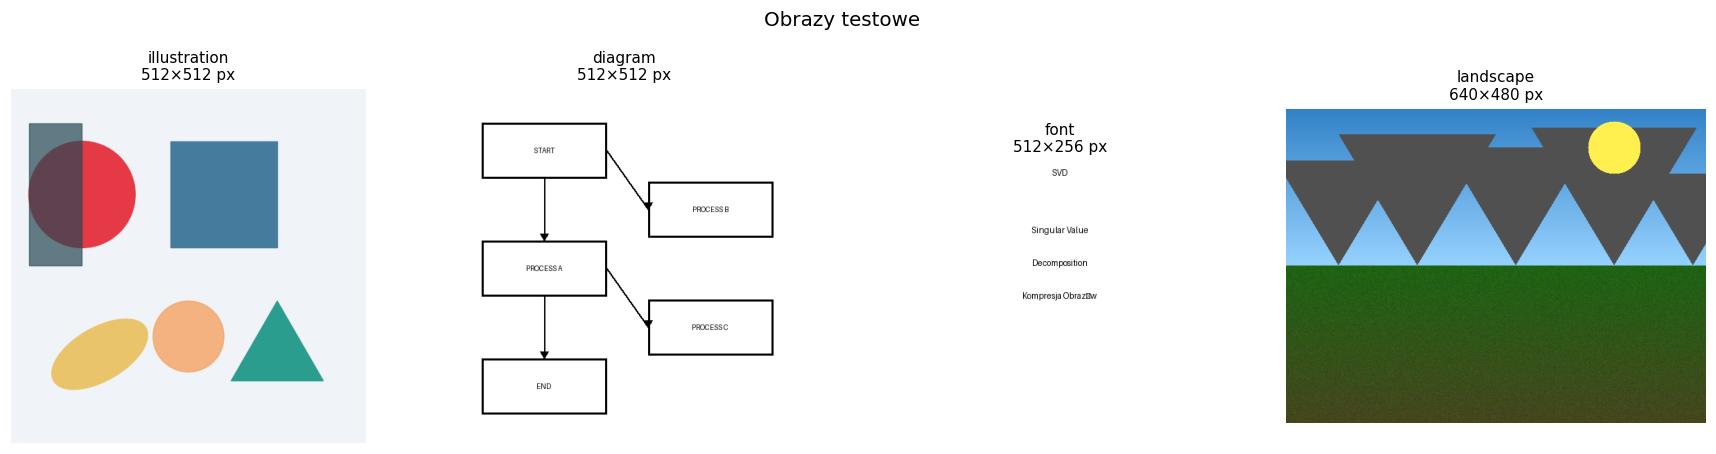


Informacje o obrazach:
         Nazwa       Rozmiar   Kanały   Eff. rank
--------------------------------------------------
  illustration    512×512          4         125
       diagram    512×512          1         103
          font    512×256          1          36
     landscape    640×480          3         357
      monalisa   1920×2861         3        1906


In [18]:
IMAGE_FILES = {
    'illustration': IMAGES_DIR / 'illustration.png',
    'diagram':      IMAGES_DIR / 'diagram.png',
    'font':         IMAGES_DIR / 'font.png',
    'landscape':    IMAGES_DIR / 'landscape.png',
    'monalisa':    IMAGES_DIR / 'monalisa.png',
}

images = {name: load_image(path) for name, path in IMAGE_FILES.items()}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, img) in zip(axes, images.items()):
    cmap = 'gray' if img.ndim == 2 else None
    ax.imshow(img, cmap=cmap)
    m, n = img.shape[:2]
    ax.set_title(f'{name}\n{n}×{m} px', fontsize=10)
    ax.axis('off')
plt.suptitle('Obrazy testowe', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nInformacje o obrazach:")
print(f"{'Nazwa':>14}  {'Rozmiar':>12}  {'Kanały':>7}  {'Eff. rank':>10}")
print("-" * 50)
for name, img in images.items():
    shape = img.shape
    m, n = shape[:2]
    ch = shape[2] if img.ndim == 3 else 1
    er = effective_rank(img)
    print(f"{name:>14}  {n:5}×{m:<5}  {ch:>7}  {er:>10}")

## 8. Wizualizacja kompresji rank-k dla każdego obrazu

Poniższa wizualizacja pokazuje, jak zmiana liczby składowych $k$ wpływa na wygląd obrazu oraz na wskaźnik kompresji i PSNR. Jest to podstawowy test wrażliwości jakości na parametr $k$.

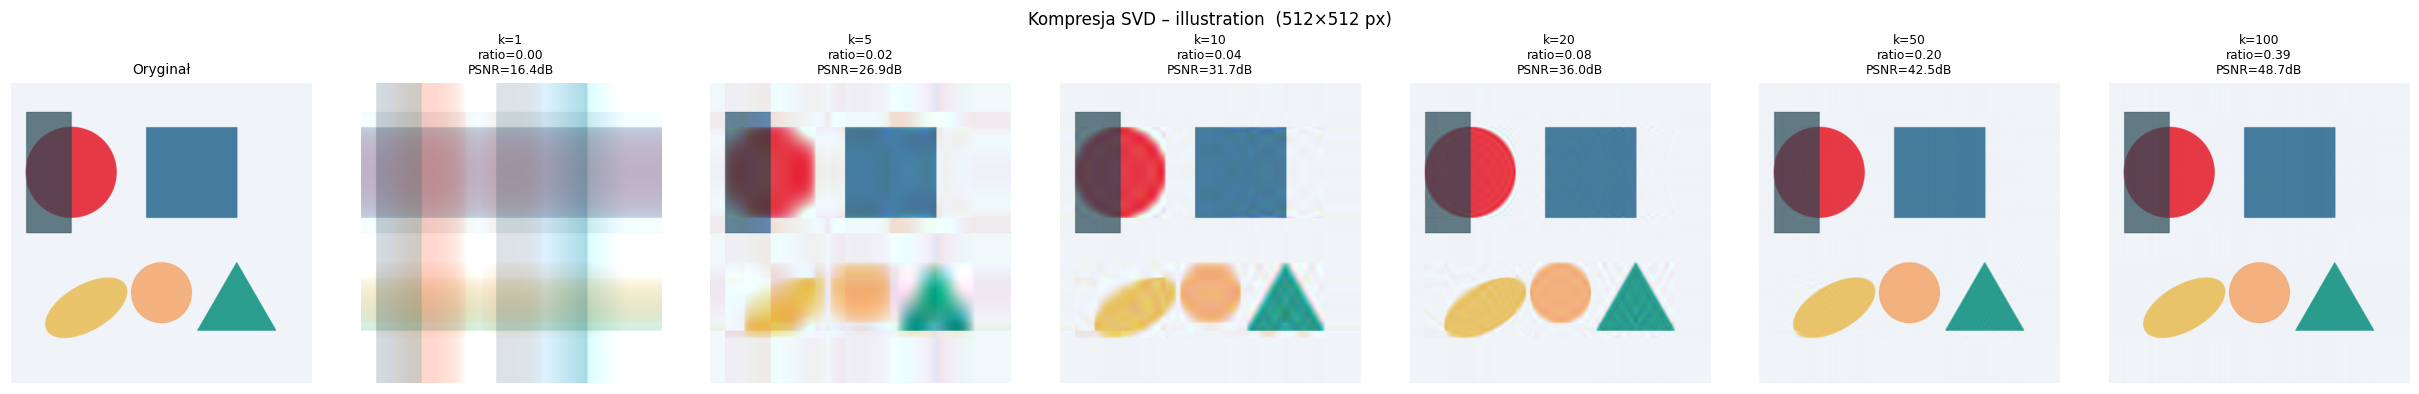

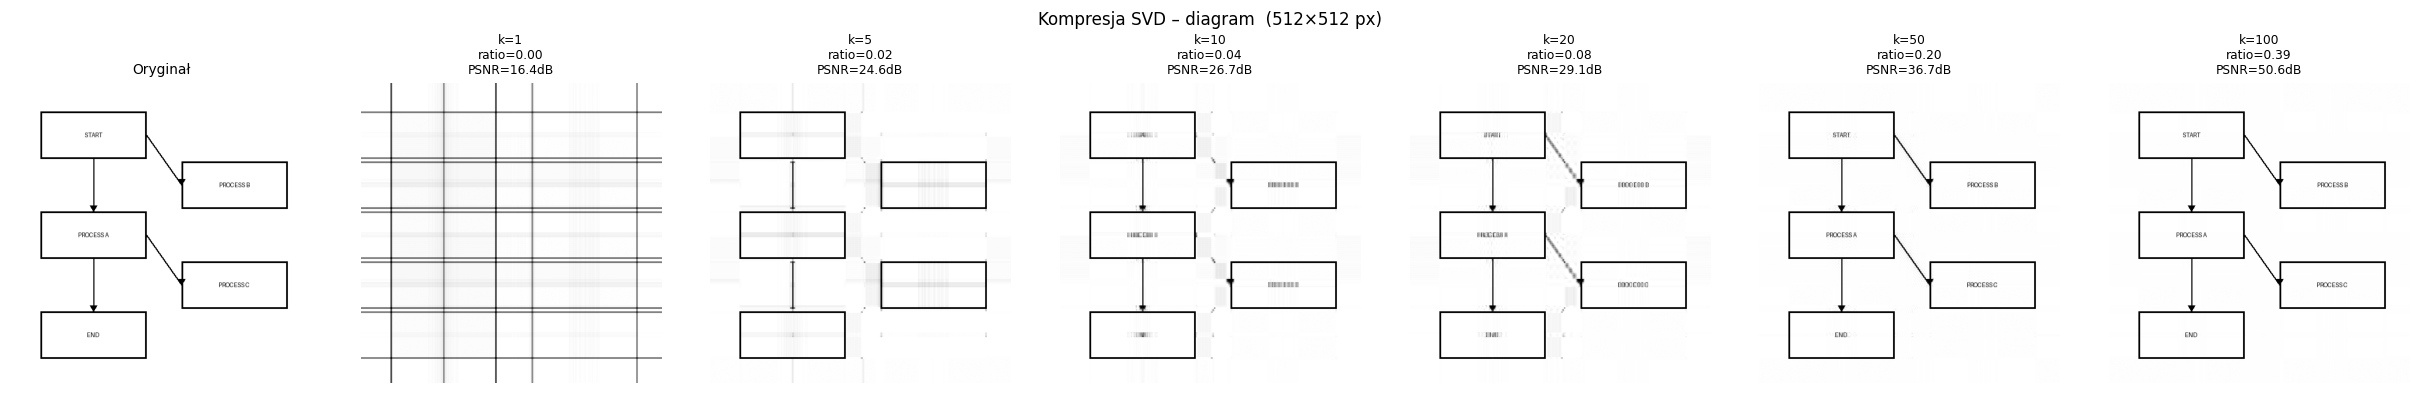

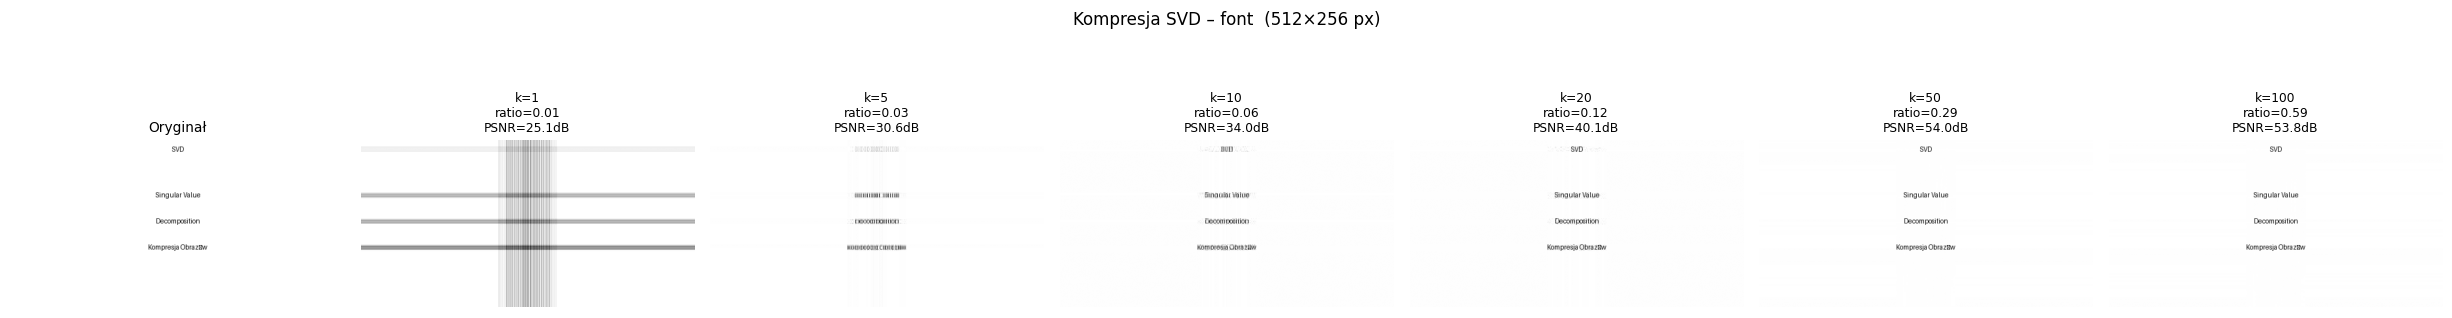

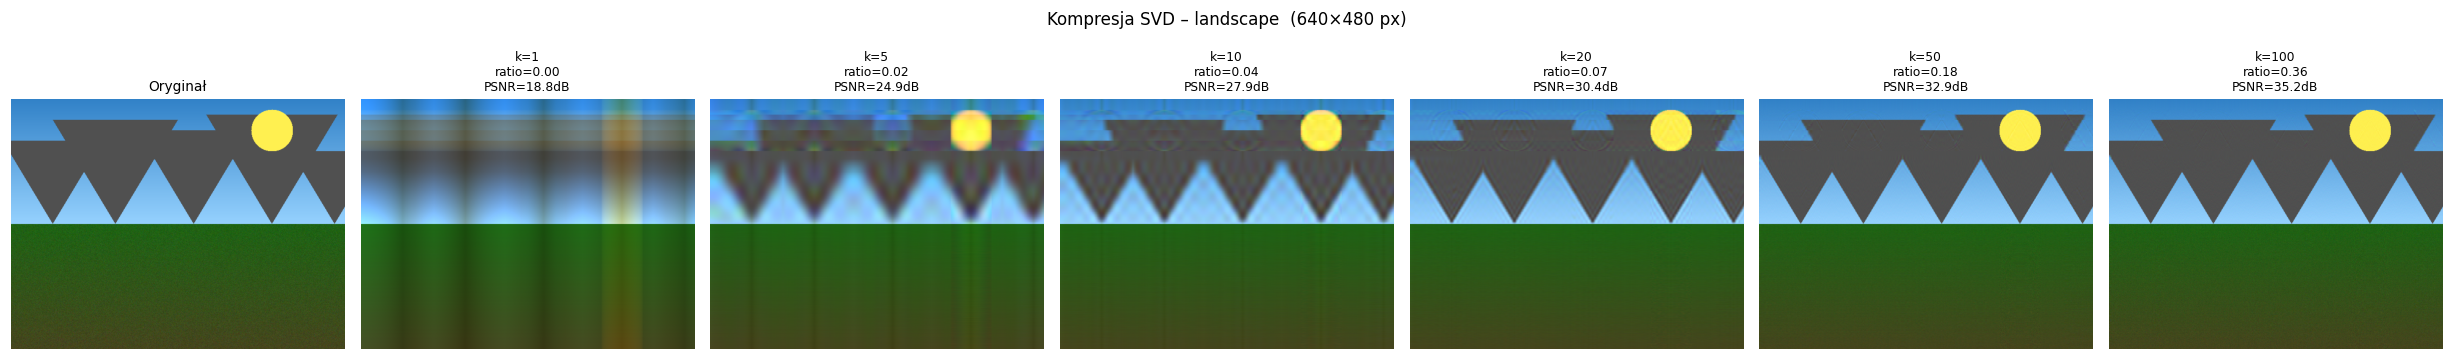

In [9]:
K_VALUES = [1, 5, 10, 20, 50, 100]

for name, img in images.items():
    m, n = img.shape[:2]
    ncols = len(K_VALUES) + 1
    fig, axes = plt.subplots(1, ncols, figsize=(3.2 * ncols, 3.5))
    cmap = 'gray' if img.ndim == 2 else None

    # Oryginał
    axes[0].imshow(img, cmap=cmap)
    axes[0].set_title('Oryginał', fontsize=9)
    axes[0].axis('off')

    for ax, k in zip(axes[1:], K_VALUES):
        k_eff = min(k, min(m, n))
        compressed = compress_image(img, filter_topk(k_eff))
        ratio = compression_ratio(m, n, k_eff)
        p = psnr(img, compressed)
        ax.imshow(compressed, cmap=cmap)
        ax.set_title(f'k={k_eff}\nratio={ratio:.2f}\nPSNR={p:.1f}dB', fontsize=8)
        ax.axis('off')

    plt.suptitle(f'Kompresja SVD – {name}  ({n}×{m} px)', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

## 9. Spektrum wartości osobliwych

Wykresy wartości osobliwych i energii skumulowanej pozwalają ocenić, jak szybko obraz traci informacje przy redukcji rzędu. Im szybszy spadek, tym łatwiejsza kompresja przy małej stracie jakości.

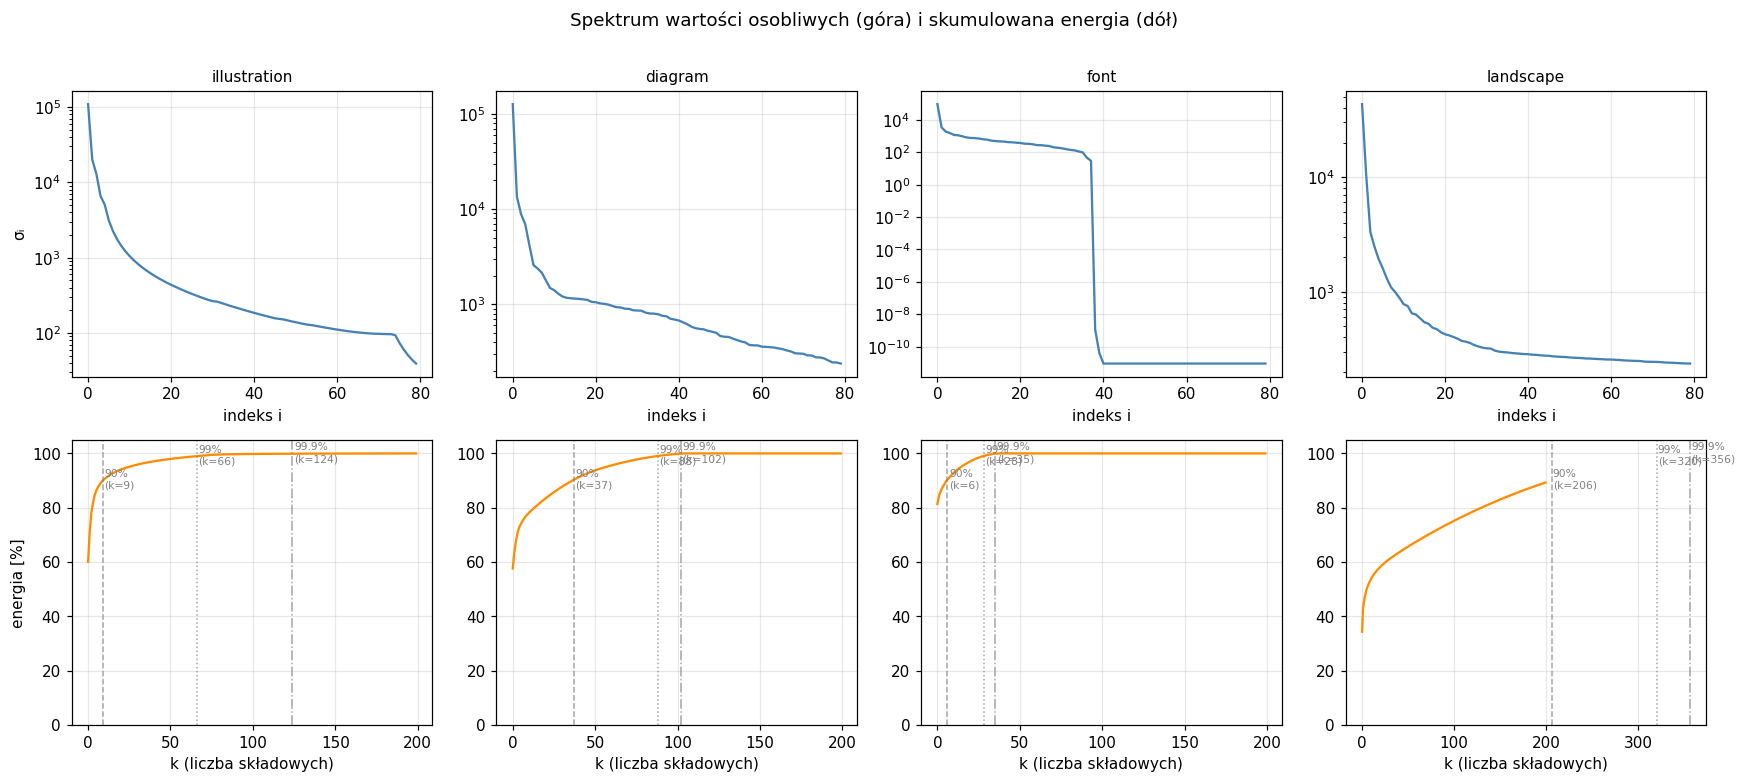

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for col, (name, img) in enumerate(images.items()):
    ch = img if img.ndim == 2 else img[:, :, 0]
    _, S, _ = np.linalg.svd(ch.astype(float), full_matrices=False)

    # Górna rzędna – wartości osobliwe
    ax = axes[0, col]
    ax.plot(S[:80], color='steelblue', linewidth=1.5)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('indeks i')
    ax.set_ylabel('σᵢ' if col == 0 else '')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    # Dolna rzędna – skumulowana energia
    ax2 = axes[1, col]
    cumulative = np.cumsum(S) / np.sum(S) * 100
    ax2.plot(cumulative[:200], color='darkorange', linewidth=1.5)
    for threshold, ls in [(90, '--'), (99, ':'), (99.9, '-.')]:
        k_t = int(np.searchsorted(cumulative, threshold))
        ax2.axvline(k_t, linestyle=ls, color='gray', alpha=0.7, linewidth=1)
        ax2.text(k_t + 1, threshold - 3, f'{threshold}%\n(k={k_t})', fontsize=7, color='gray')
    ax2.set_xlabel('k (liczba składowych)')
    ax2.set_ylabel('energia [%]' if col == 0 else '')
    ax2.set_ylim(0, 105)
    ax2.grid(True, alpha=0.3)

plt.suptitle('Spektrum wartości osobliwych (góra) i skumulowana energia (dół)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 10. PSNR i MSE w funkcji k

W tej sekcji porównywane są metryki PSNR i MSE w funkcji $k$. Pozwala to znaleźć zakresy, w których dalsze zwiększanie $k$ daje już niewielką poprawę jakości.

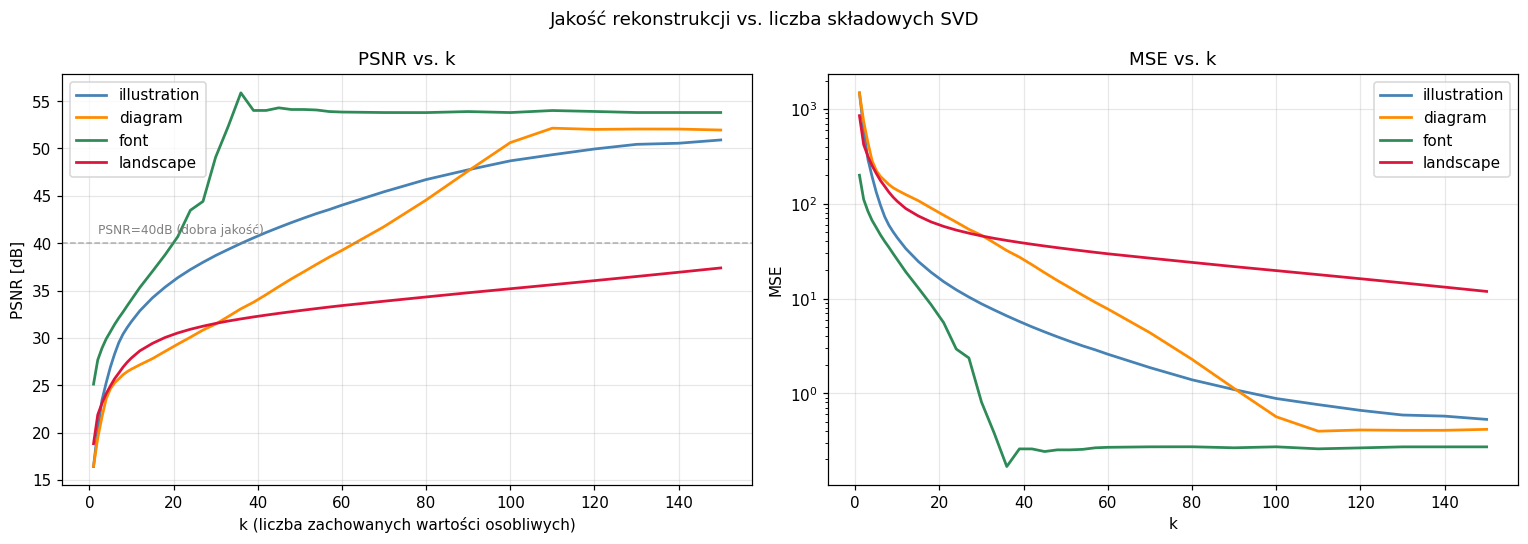

In [11]:
k_range = list(range(1, 11)) + list(range(12, 60, 3)) + list(range(60, 151, 10))
results = {}  # name -> {'k': [...], 'psnr': [...], 'mse': [...], 'ratio': [...]}

for name, img in images.items():
    m, n = img.shape[:2]
    max_k = min(m, n)
    ks, psnrs, mses, ratios = [], [], [], []
    for k in k_range:
        if k > max_k:
            break
        comp = compress_image(img, filter_topk(k))
        ks.append(k)
        psnrs.append(psnr(img, comp))
        mses.append(mse(img, comp))
        ratios.append(compression_ratio(m, n, k))
    results[name] = {'k': ks, 'psnr': psnrs, 'mse': mses, 'ratio': ratios}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for (name, data), color in zip(results.items(), colors):
    ax1.plot(data['k'], data['psnr'], label=name, color=color, linewidth=1.8)
    ax2.plot(data['k'], data['mse'],  label=name, color=color, linewidth=1.8)

ax1.set_xlabel('k (liczba zachowanych wartości osobliwych)')
ax1.set_ylabel('PSNR [dB]')
ax1.set_title('PSNR vs. k')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.axhline(40, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.text(2, 41, 'PSNR=40dB (dobra jakość)', fontsize=8, color='gray')

ax2.set_xlabel('k')
ax2.set_ylabel('MSE')
ax2.set_title('MSE vs. k')
ax2.set_yscale('log')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Jakość rekonstrukcji vs. liczba składowych SVD', fontsize=12)
plt.tight_layout()
plt.show()

## 11. PSNR w funkcji wskaźnika kompresji

Tutaj jakość rekonstrukcji jest odnoszona bezpośrednio do wskaźnika kompresji $r$. Takie ujęcie ułatwia porównanie obrazów o różnych rozmiarach.

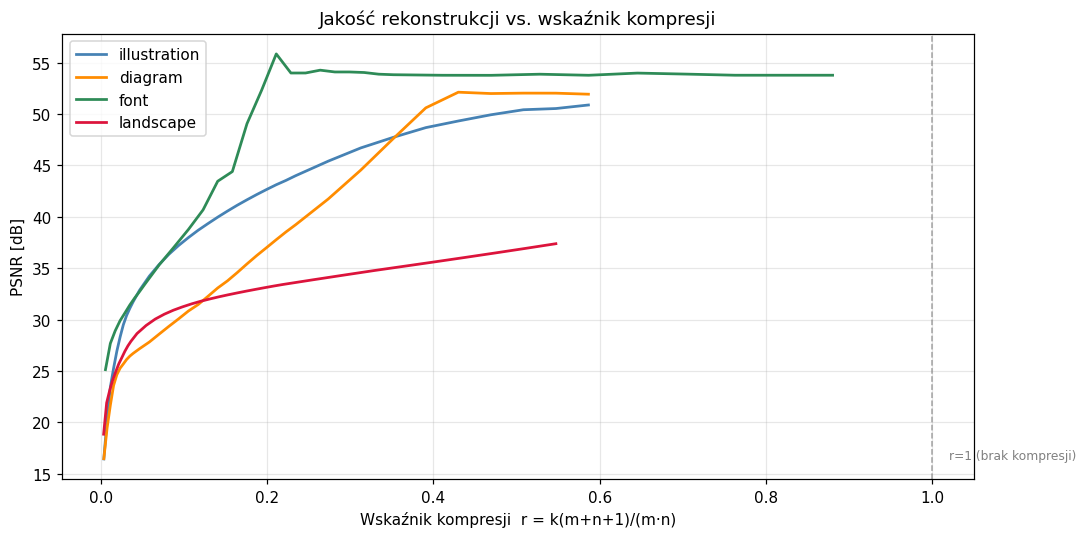

Wskaźnik kompresji < 1 oznacza, że zapis SVD-k zajmuje MNIEJ miejsca niż oryginał.


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for (name, data), color in zip(results.items(), colors):
    ax.plot(data['ratio'], data['psnr'], label=name, color=color, linewidth=1.8)

ax.set_xlabel('Wskaźnik kompresji  r = k(m+n+1)/(m·n)')
ax.set_ylabel('PSNR [dB]')
ax.set_title('Jakość rekonstrukcji vs. wskaźnik kompresji')
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(1.02, ax.get_ylim()[0] + 2, 'r=1 (brak kompresji)', fontsize=8, color='gray')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Wskaźnik kompresji < 1 oznacza, że zapis SVD-k zajmuje MNIEJ miejsca niż oryginał.")

## 12. Porównanie filtrów na obrazie testowym

Ten fragment porównuje różne strategie modyfikacji wektora $S$, aby pokazać różnice między twardym obcięciem, progowaniem i wzmocnieniem dominujących składowych. Jest to test bardziej użytkowy niż czysto numeryczny.

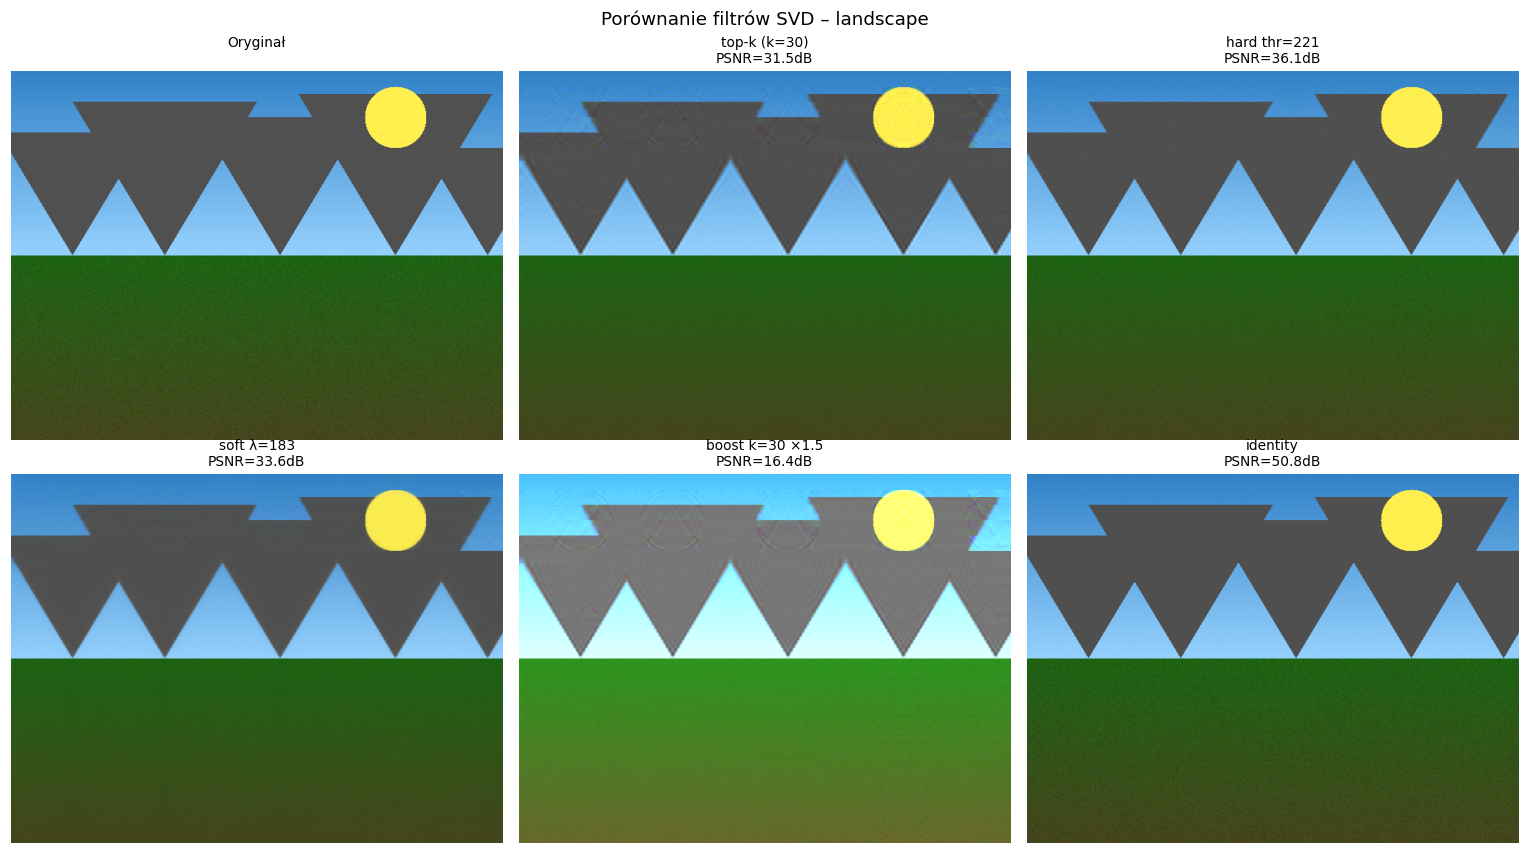

In [13]:
TEST_IMAGE_NAME = 'landscape'
img_test = images[TEST_IMAGE_NAME]
m, n = img_test.shape[:2]

# Wyznacz próg soft-threshold na podstawie mediany wartości osobliwych
ch0 = img_test if img_test.ndim == 2 else img_test[:, :, 0]
_, S0, _ = np.linalg.svd(ch0.astype(float), full_matrices=False)
lam_soft = float(np.percentile(S0, 70))   # 70-ty percentyl
thr_hard  = float(np.percentile(S0, 80))

K_TEST = 30

filters = [
    ('Oryginał',            None),
    (f'top-k (k={K_TEST})', filter_topk(K_TEST)),
    (f'hard thr={thr_hard:.0f}', filter_threshold(thr_hard)),
    (f'soft λ={lam_soft:.0f}',   filter_soft_threshold(lam_soft)),
    (f'boost k={K_TEST} ×1.5',   filter_boost(K_TEST, 1.5)),
    ('identity',            filter_identity),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cmap = 'gray' if img_test.ndim == 2 else None

for ax, (label, fn) in zip(axes.flat, filters):
    if fn is None:
        out = img_test
        subtitle = ''
    else:
        out = compress_image(img_test, fn)
        p = psnr(img_test, out)
        cr = compression_ratio(m, n, K_TEST) if 'top' in label or 'boost' in label else compression_ratio(m, n, int(np.sum(S0 >= thr_hard)))
        subtitle = f'PSNR={p:.1f}dB'
    ax.imshow(out, cmap=cmap)
    ax.set_title(f'{label}\n{subtitle}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Porównanie filtrów SVD – {TEST_IMAGE_NAME}', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Tabela podsumowująca – wskaźniki kompresji

Tabela zbiera najważniejsze wskaźniki w jednym miejscu, co ułatwia raportowanie wyników. W szczególności interesuje nas $k$ potrzebne do przekroczenia zadanej jakości oraz $k$ odpowiadające zadanej energii.

In [14]:
TARGET_PSNR = 35.0  # dB – próg akceptowalnej jakości

print(f"{'Obraz':>14} {'m×n':>10} {'k@PSNR≥35dB':>12} {'ratio@35dB':>11} {'k@99%':>8} {'PSNR@k=50':>11}")
print("-" * 72)

for name, img in images.items():
    m, n = img.shape[:2]
    data = results[name]

    # k potrzebne do osiągnięcia PSNR >= TARGET_PSNR
    k_for_target = None
    for k, p in zip(data['k'], data['psnr']):
        if p >= TARGET_PSNR:
            k_for_target = k
            break

    ratio_at_target = compression_ratio(m, n, k_for_target) if k_for_target else float('nan')

    # k dla 99% energii
    ch = img if img.ndim == 2 else img[:, :, 0]
    _, S, _ = np.linalg.svd(ch.astype(float), full_matrices=False)
    cumE = np.cumsum(S) / np.sum(S)
    k_99 = int(np.searchsorted(cumE, 0.99)) + 1

    # PSNR przy k=50
    k50 = min(50, min(m, n))
    comp50 = compress_image(img, filter_topk(k50))
    p50 = psnr(img, comp50)

    k_str = str(k_for_target) if k_for_target else 'N/A'
    r_str = f'{ratio_at_target:.3f}' if k_for_target else 'N/A'
    print(f"{name:>14} {n:>4}×{m:<4} {k_str:>12} {r_str:>11} {k_99:>8} {p50:>10.1f}dB")

         Obraz        m×n  k@PSNR≥35dB  ratio@35dB    k@99%   PSNR@k=50
------------------------------------------------------------------------
  illustration  512×512            18       0.070       67       42.5dB
       diagram  512×512            45       0.176       89       36.7dB
          font  512×256            12       0.070       29       54.0dB
     landscape  640×480           100       0.365      321       32.9dB


## 14. Demo interaktywne – wybór k i filtru

Sekcja demonstracyjna pozwala szybko sprawdzić wpływ parametru $k$ i wybranego filtru na wygląd obrazu. Jest to wygodne narzędzie do jakościowej oceny wyników bez przebudowy całych wykresów.

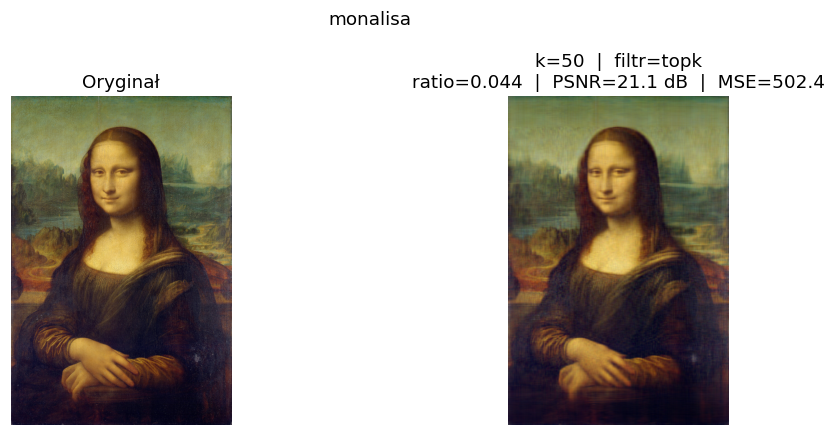

In [ ]:
def demo(image_name: str, k: int = 20, filter_name: str = 'topk'):
    """
    Szybkie demo: wyświetla oryginał i skompresowaną wersję obok siebie.

    Parametry
    ---------
    image_name  : 'illustration' | 'diagram' | 'font' | 'landscape'
    k           : liczba zachowanych wartości osobliwych
    filter_name : 'topk' | 'threshold' | 'soft' | 'boost'
    """
    img = images[image_name]
    m, n = img.shape[:2]
    k = min(k, min(m, n))

    _, S, _ = np.linalg.svd(
        (img if img.ndim == 2 else img[:, :, 0]).astype(float), full_matrices=False
    )

    fn_map = {
        'topk':      filter_topk(k),
        'threshold': filter_threshold(float(np.percentile(S, 70))),
        'soft':      filter_soft_threshold(float(np.percentile(S, 60))),
        'boost':     filter_boost(k, 1.5),
    }
    fn = fn_map[filter_name]
    comp = compress_image(img, fn)
    cr = compression_ratio(m, n, k)
    p  = psnr(img, comp)

    cmap = 'gray' if img.ndim == 2 else None
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.imshow(img, cmap=cmap);   ax1.set_title('Oryginał');       ax1.axis('off')
    ax2.imshow(comp, cmap=cmap);  ax2.axis('off')
    ax2.set_title(
        f'k={k}  |  filtr={filter_name}\n'
        f'ratio={cr:.3f}  |  PSNR={p:.1f} dB  |  MSE={mse(img, comp):.1f}'
    )
    plt.suptitle(image_name, fontsize=12)
    plt.tight_layout()
    plt.show()

# ── Przykłady ──────────────────────────────────────────────────────────────────
demo('diagram',      k=10,  filter_name='topk')
demo('landscape',    k=50,  filter_name='topk')
demo('font',         k=15,  filter_name='topk')
demo('illustration', k=30,  filter_name='topk')
demo('monalisa',     k=50,  filter_name='topk')

### Interaktywny suwak (k, filtr, obraz)

Mini-panel z suwakami i listą wyboru, który pozwala na żywo zmieniać `k` i typ filtru dla wybranego obrazu.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    def _interactive_demo(image_name: str, k: int, filter_name: str):
        img = images[image_name]
        m, n = img.shape[:2]
        k = max(1, min(k, min(m, n)))

        ch0 = img if img.ndim == 2 else img[:, :, 0]
        _, S, _ = np.linalg.svd(ch0.astype(float), full_matrices=False)

        fn_map = {
            'topk':      filter_topk(k),
            'threshold': filter_threshold(float(np.percentile(S, 70))),
            'soft':      filter_soft_threshold(float(np.percentile(S, 60))),
            'boost':     filter_boost(k, 1.5),
        }
        fn = fn_map[filter_name]
        comp = compress_image(img, fn)
        cr = compression_ratio(m, n, k)
        p = psnr(img, comp)

        cmap = 'gray' if img.ndim == 2 else None
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4))
        fig.subplots_adjust(left=0.2, right=0.8)
        ax1.imshow(img, cmap=cmap);   ax1.set_title('Oryginal');  ax1.axis('off')
        ax2.imshow(comp, cmap=cmap);  ax2.axis('off')
        ax2.set_title(
            f'k={k} | filtr={filter_name}\n'
            f'ratio={cr:.3f} | PSNR={p:.1f} dB | MSE={mse(img, comp):.1f}'
        )
        plt.tight_layout()
        plt.show()

    max_k_global = 200

    image_selector = widgets.Dropdown(
    options=list(images.keys()),
    value='landscape',
    description='obraz:',
    layout=widgets.Layout(width='220px')
)

    filter_selector = widgets.Dropdown(
        options=['topk', 'threshold', 'soft', 'boost'],
        value='topk',
        description='filtr:',
        layout=widgets.Layout(width='220px')
    )

    k_slider = widgets.IntSlider(
        value=30,
        min=1,
        max=max_k_global,
        step=1,
        description='k:',
        continuous_update=False,
        layout=widgets.Layout(width='500px')
    )

    minus_btn = widgets.Button(
        description='-',
        layout=widgets.Layout(width='40px')
    )

    plus_btn = widgets.Button(
        description='+',
        layout=widgets.Layout(width='40px')
    )

    def _dec_k(_):
        k_slider.value = max(k_slider.min, k_slider.value - k_slider.step)

    def _inc_k(_):
        k_slider.value = min(k_slider.max, k_slider.value + k_slider.step)

    minus_btn.on_click(_dec_k)
    plus_btn.on_click(_inc_k)

    # slider na środku
    k_controls = widgets.HBox(
        [minus_btn, k_slider, plus_btn],
        layout=widgets.Layout(
            justify_content='center',
            align_items='center',
            width='100%',
            margin='8px 0 0 0',
        )
    )

    # dropdowny na środku
    top_controls = widgets.HBox(
        [image_selector, filter_selector],
        layout=widgets.Layout(
            justify_content='center',
            align_items='center',
            gap='20px',
            width='100%',
        )
    )

    # cały layout
    ui = widgets.VBox(
        [top_controls, k_controls],
        layout=widgets.Layout(
            align_items='center',
            width='100%',
            padding='16px 24px',
            border='1px solid #ddd',
            margin='0 auto 16px auto',
        )
    )

    out = widgets.interactive_output(
        _interactive_demo,
        {'image_name': image_selector, 'k': k_slider, 'filter_name': filter_selector}
    )

    display(ui, out)
except ImportError:
    print('Brak ipywidgets. Zainstaluj: pip install ipywidgets')

Output()

## 15. Wnioski

### Jak działa kompresja SVD?

Obraz traktowany jest jako macierz pikseli $A \in \mathbb{R}^{m \times n}$. Rozkład SVD daje
$A = U\Sigma V^T$, gdzie wartości osobliwe $\sigma_i$ opisują 'wklad' każdego kierunku w strukturę obrazu.
Przybliżenie $A_k$ zachowuje tylko $k$ największych $\sigma_i$ - efektywnie przechowuje
$k(m + n + 1)$ liczb zamiast $mn$.

### Obserwacje z testów

| Typ obrazu     | Charakter spektrum σ | Wymagane k dla PSNR≥35dB | Wniosek |
|----------------|---------------------|---------------------------|---------|
| **diagram**    | Skokowe opadanie (kilka dominant) | Bardzo małe (<15) | Idealny do SVD – niska ranga efektywna |
| **font**       | Powolne opadanie    | Małe (~20)          | Dobrze się kompresuje - dominują proste linie |
| **illustration** | Umiarkowane       | Średnie (~30)        | Kształty = kilka dominant |
| **landscape**  | Powolne, długi ogon | Duże (>50)           | Foto/szum wymaga wielu składowych |

### Funkcja filtrująca

- **Top-k** - najlepsza do kompresji, gwarantuje dokładną kontrolę nad `k`.
- **Hard threshold** - prosta, ale trudno z góry przewidzieć wynikowe `k`.
- **Soft threshold** - łagodniejsze przejście, przydatny do odszumiania.
- **Boost** - wzmacnia dominujące kierunki (efekt artystyczny / podbicie kontrastu).

### Ograniczenia SVD

- SVD nie uwzględnia lokalnej struktury (bloki, krawędzie) - stąd gorsza wydajność niż JPEG/WebP na zdjęciach.
- Dla dużych obrazów obliczenie pełnego SVD jest kosztowne ($O(mn^2)$); można użyć **truncated SVD** (np. `scipy.sparse.linalg.svds`).
- Każdy kanał RGB kompresowany osobno - korelacje między kanałami nie są wykorzystywane.